# `witwin.channel.deterministic.solve_field` Multipath Example

This notebook uses `witwin.channel.deterministic.solve_field`, `witwin.channel.core.scene`, and `witwin.core` to solve a dense field plane and compare AD-vs-FD power gradients on the three-cube multipath scene. It renders the forward field at the 256 x 256 grid and 1280 reflection-ray settings used by `tests/main/test_multipath_main.py`, while AD-vs-FD gradient and backward VJP checks use smaller bounded workloads so the notebook can run reliably.


jitc_llvm_init(): LLVM API initialization failed ..


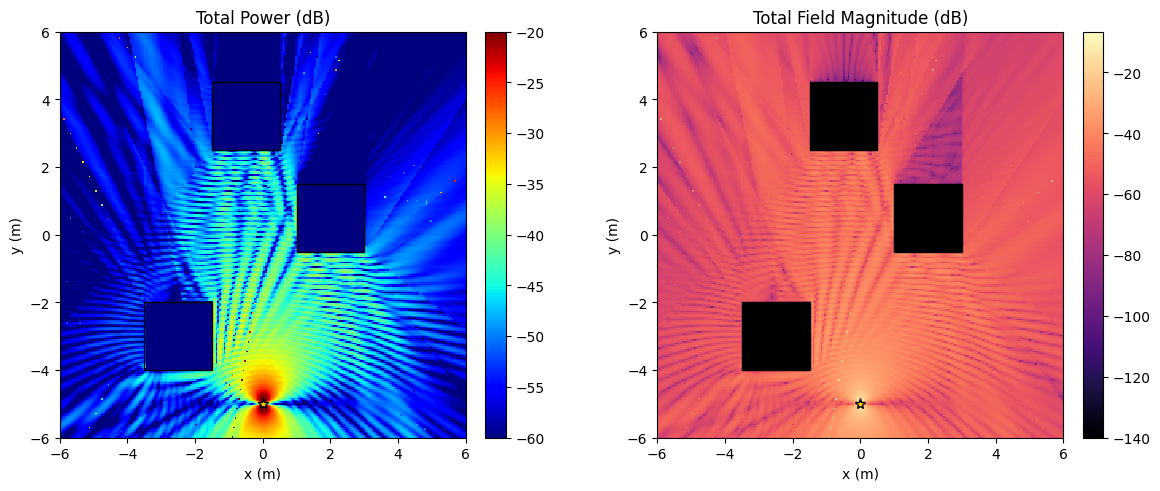

{'shape': (256, 256),
 'reflection_backend': None,
 'reflection_policy': None,
 'num_samples': 1280,
 'max_diffraction_order': 2,
 'power_min': 0.0,
 'power_max': 0.21906566619873047}

In [1]:
from pathlib import Path
import importlib
import math
import sys

from IPython.display import display
import matplotlib.pyplot as plt

repo_root = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / 'witwin' / 'channel' / 'deterministic').exists()
)
examples_dir = repo_root / 'examples'
for path in (examples_dir, repo_root):
    path_str = str(path)
    sys.path = [entry for entry in sys.path if str(Path(entry or '.').resolve()) != path_str]
    sys.path.insert(0, path_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == 'witwin' or module_name.startswith(('witwin.', 'field_solver_multipath_main')):
        sys.modules.pop(module_name, None)

import field_solver_multipath_main as field_example

field_example = importlib.reload(field_example)
ThreeCubeFieldExperiment = field_example.ThreeCubeFieldExperiment
plot_forward = field_example.plot_forward
plot_gradient = field_example.plot_gradient
GRID_SHAPE = field_example.DEFAULT_GRID_SHAPE
REFLECTION_N_RAYS = field_example.DEFAULT_REFLECTION_N_RAYS
MAX_DIFFRACTIONS = field_example.DEFAULT_MAX_DIFFRACTIONS
FD_STEP = field_example.DEFAULT_FD_STEP
GRADIENT_GRID_SHAPE = (64, 64)
GRADIENT_REFLECTION_N_RAYS = 128
GRADIENT_MAX_DIFFRACTIONS = 1

experiment = ThreeCubeFieldExperiment(
    grid_shape=GRID_SHAPE,
    num_samples=REFLECTION_N_RAYS,
    max_diffraction_order=MAX_DIFFRACTIONS,
)
forward_result = experiment.solve()
forward = experiment.snapshot(forward_result)
plot_forward(forward)
plt.show()
reflection_meta = dict(forward_result.metadata['reflection'])
display({
    'shape': tuple(int(value) for value in forward.total_power.shape),
    'reflection_backend': reflection_meta.get('epc_stats', {}).get('backend'),
    'reflection_policy': reflection_meta.get('epc_stats', {}).get('policy'),
    'num_samples': REFLECTION_N_RAYS,
    'max_diffraction_order': MAX_DIFFRACTIONS,
    'power_min': float(forward.total_power.min()),
    'power_max': float(forward.total_power.max()),
})

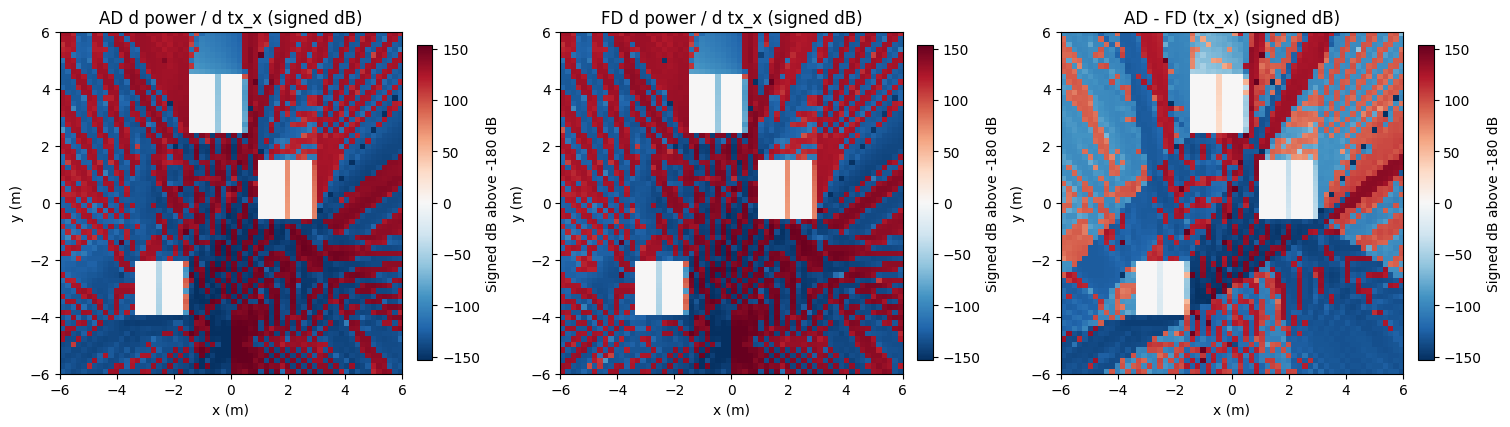

{'shape': (64, 64),
 'num_samples': 128,
 'max_diffraction_order': 1,
 'tx_x_ad_l1': 1.8249571095436201,
 'tx_x_fd_l1': 1.7412989320587107,
 'tx_x_delta_l1': 0.19832393453086336}

In [2]:
tx_x = experiment.gradient(
    'tx_x',
    grid_shape=GRADIENT_GRID_SHAPE,
    num_samples=GRADIENT_REFLECTION_N_RAYS,
    max_diffraction_order=GRADIENT_MAX_DIFFRACTIONS,
    fd_step=FD_STEP,
)
plot_gradient(tx_x)
plt.show()
display({
    'shape': tuple(int(value) for value in tx_x.ad.shape),
    'num_samples': GRADIENT_REFLECTION_N_RAYS,
    'max_diffraction_order': GRADIENT_MAX_DIFFRACTIONS,
    'tx_x_ad_l1': float(abs(tx_x.ad).sum()),
    'tx_x_fd_l1': float(abs(tx_x.fd).sum()),
    'tx_x_delta_l1': float(abs(tx_x.delta).sum()),
})

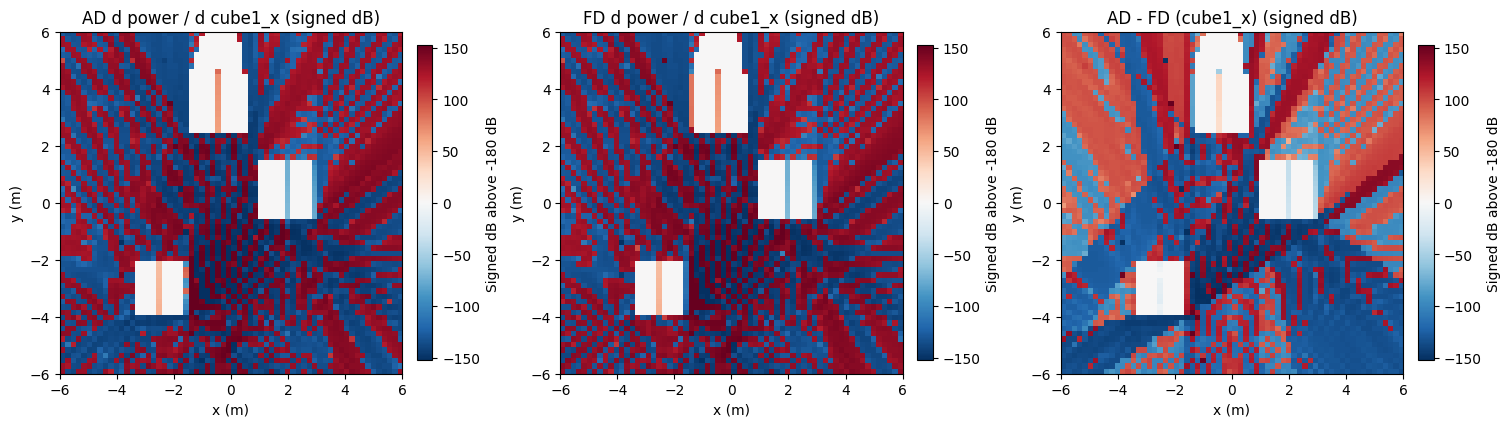

{'shape': (64, 64),
 'num_samples': 128,
 'max_diffraction_order': 1,
 'cube1_x_ad_l1': 0.604736306285488,
 'cube1_x_fd_l1': 0.5623661691927312,
 'cube1_x_delta_l1': 0.12654831636296834}

In [3]:
cube1_x = experiment.gradient(
    'cube1_x',
    grid_shape=GRADIENT_GRID_SHAPE,
    num_samples=GRADIENT_REFLECTION_N_RAYS,
    max_diffraction_order=GRADIENT_MAX_DIFFRACTIONS,
    fd_step=FD_STEP,
)
plot_gradient(cube1_x)
plt.show()
display({
    'shape': tuple(int(value) for value in cube1_x.ad.shape),
    'num_samples': GRADIENT_REFLECTION_N_RAYS,
    'max_diffraction_order': GRADIENT_MAX_DIFFRACTIONS,
    'cube1_x_ad_l1': float(abs(cube1_x.ad).sum()),
    'cube1_x_fd_l1': float(abs(cube1_x.fd).sum()),
    'cube1_x_delta_l1': float(abs(cube1_x.delta).sum()),
})

In [4]:
# Backward/VJP smoke check
backward_experiment = ThreeCubeFieldExperiment(
    grid_shape=(16, 16),
    num_samples=16,
    reflection_max_bounces=0,
    max_diffraction_order=0,
)
backward_checks = {
    parameter: backward_experiment.backward(
        parameter,
        grid_shape=(8, 8),
        num_samples=32,
        max_diffraction_order=0,
        enable_rd_diffraction=False,
        fd_step=FD_STEP,
    )
    for parameter in ('tx_x', 'cube1_x')
}
summary = {
    parameter: {
        'vjp': float(snapshot.vjp),
        'jvp_sum': float(snapshot.jvp_sum),
        'fd_sum': float(snapshot.fd_sum),
        'vjp_minus_jvp_sum': float(snapshot.vjp_delta),
        'vjp_minus_fd_sum': float(snapshot.fd_delta),
    }
    for parameter, snapshot in backward_checks.items()
}
display(summary)
for snapshot in backward_checks.values():
    assert math.isfinite(snapshot.vjp)
    assert abs(snapshot.vjp_delta) <= max(1.0e-7, 1.0e-4 * max(1.0, abs(snapshot.jvp_sum)))


{'tx_x': {'vjp': 3.4729429899016395e-05,
  'jvp_sum': 3.472885293831496e-05,
  'fd_sum': 3.4769982448779047e-05,
  'vjp_minus_jvp_sum': 5.769607014372014e-10,
  'vjp_minus_fd_sum': -4.0552549762651324e-08},
 'cube1_x': {'vjp': 0.0,
  'jvp_sum': 0.0,
  'fd_sum': 0.0,
  'vjp_minus_jvp_sum': 0.0,
  'vjp_minus_fd_sum': 0.0}}